# Foreground/Background Segmentation using PyTorch

This notebook demonstrates how to perform foreground/background segmentation using a pre-trained PyTorch model. We'll use the DeepLabV3 model from torchvision to segment images from your available datasets.

## Overview
- Load and explore image datasets (bell, buddha, duck, templeRing)
- Use pre-trained DeepLabV3 model for semantic segmentation
- Extract foreground/background masks
- Visualize and compare results across different datasets

## Requirements
- PyTorch and torchvision for deep learning
- OpenCV and PIL for image processing
- NumPy and Matplotlib for data handling and visualization

In [2]:
# Install ben2
!pip install git+https://github.com/PramaLLC/BEN2.git

  Cloning https://github.com/PramaLLC/BEN2.git to /tmp/pip-req-build-x95_b84m
  Running command git clone --filter=blob:none --quiet https://github.com/PramaLLC/BEN2.git /tmp/pip-req-build-x95_b84m
  Resolved https://github.com/PramaLLC/BEN2.git to commit 41efc6966a6fcaf77dfd90ecd4cf06a1edcd1745
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
# Import necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import glob
from pathlib import Path

# PyTorch libraries
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision import models
import torchvision.transforms.functional as TF

# ben2
from ben2 import AutoModel

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set up matplotlib for better visualization
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['axes.grid'] = False

print("Libraries imported successfully!")

Using device: cuda
Libraries imported successfully!


## 1. Dataset Loading and Exploration

Let's start by loading images from the available datasets and exploring their characteristics.

In [4]:
# Define paths to datasets
base_path = Path("/files/Doutorado/2025s2/MO446/T2")
# datasets = {
#     'bell': base_path / "dataset_bell",
#     'buddha': base_path / "dataset_buddha" / "buddha",
#     'duck': base_path / "dataset_duck",
#     'templeRing': base_path / "dataset_templeRing"
# }

datasets = {
    'duck_rot': base_path / "dataset_duck_rot",
}

def load_images_from_dataset(dataset_path, max_images=5):
    """Load sample images from a dataset directory"""
    image_extensions = ['*.png', '*.jpg', '*.jpeg']
    images = []
    
    for ext in image_extensions:
        images.extend(glob.glob(str(dataset_path / ext)))
    
    # Sort and limit number of images
    images = sorted(images)[:max_images]
    
    loaded_images = []
    for img_path in images:
        try:
            # Load image with PIL
            img = Image.open(img_path)
            loaded_images.append((img, Path(img_path).name))
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
    
    return loaded_images

# Load sample images from each dataset
dataset_images = {}
for name, path in datasets.items():
    if path.exists():
        print(f"Loading images from {name} dataset...")
        dataset_images[name] = load_images_from_dataset(path, max_images=3)
        print(f"Loaded {len(dataset_images[name])} images from {name}")
    else:
        print(f"Dataset {name} not found at {path}")

print(f"\nTotal datasets loaded: {len(dataset_images)}")

Loading images from duck_rot dataset...
Loaded 3 images from duck_rot

Total datasets loaded: 1


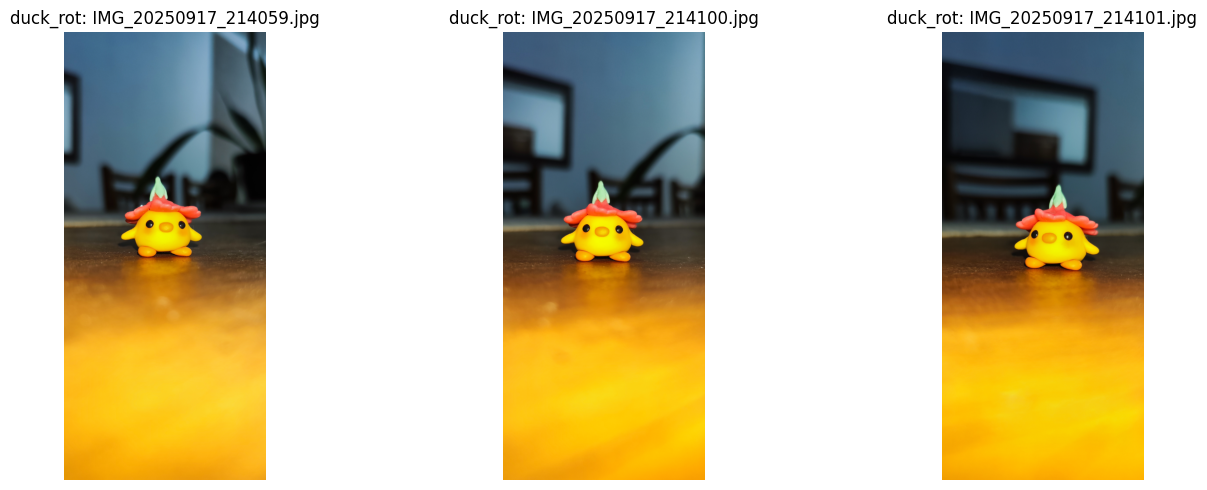

In [5]:
# Display sample images from each dataset
def display_dataset_samples(dataset_images):
    """Display sample images from all datasets"""
    fig, axes = plt.subplots(len(dataset_images), 3, figsize=(15, 5*len(dataset_images)))
    
    if len(dataset_images) == 1:
        axes = axes.reshape(1, -1)
    
    for i, (dataset_name, images) in enumerate(dataset_images.items()):
        for j, (img, img_name) in enumerate(images[:3]):
            if j < 3:  # Show up to 3 images per dataset
                axes[i, j].imshow(img)
                axes[i, j].set_title(f"{dataset_name}: {img_name}")
                axes[i, j].axis('off')
        
        # Hide empty subplots
        for k in range(len(images), 3):
            axes[i, k].axis('off')
    
    plt.tight_layout()
    plt.show()

# Display the loaded images
if dataset_images:
    display_dataset_samples(dataset_images)
else:
    print("No images loaded. Please check dataset paths.")

## 2. Pre-trained Segmentation Model

We'll use DeepLabV3 with ResNet-101 backbone, pre-trained on COCO dataset. This model can identify multiple object classes and we'll use it to separate foreground objects from background.

In [6]:
# # Load pre-trained DeepLabV3 model
# print("Loading pre-trained DeepLabV3 model...")
# model = models.segmentation.deeplabv3_resnet101(pretrained=True)
# model.eval()
# model = model.to(device)
# print("Model loaded successfully!")

# # COCO dataset class names (21 classes for DeepLabV3)
# # 0: background, 1-20: various object classes
# COCO_CLASSES = [
#     'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
#     'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
#     'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
# ]

# print(f"Model can segment {len(COCO_CLASSES)} classes: {COCO_CLASSES}")

/home/ebneto/miniconda3/envs/viscomp/lib/python3.13/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


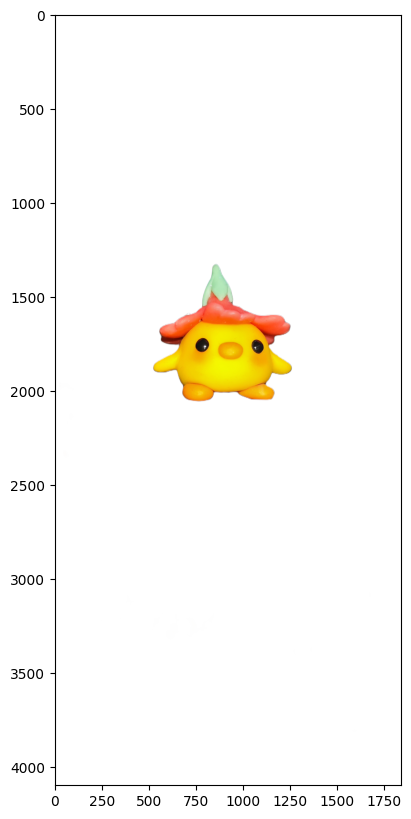

In [7]:
model = AutoModel.from_pretrained("PramaLLC/BEN2") # repo_id
model.to(device).eval()
foreground = model.inference(Image.open('../dataset_duck_rot/IMG_20250917_214059.jpg'))
plt.imshow(foreground)

Segmenting images from duck_rot dataset...


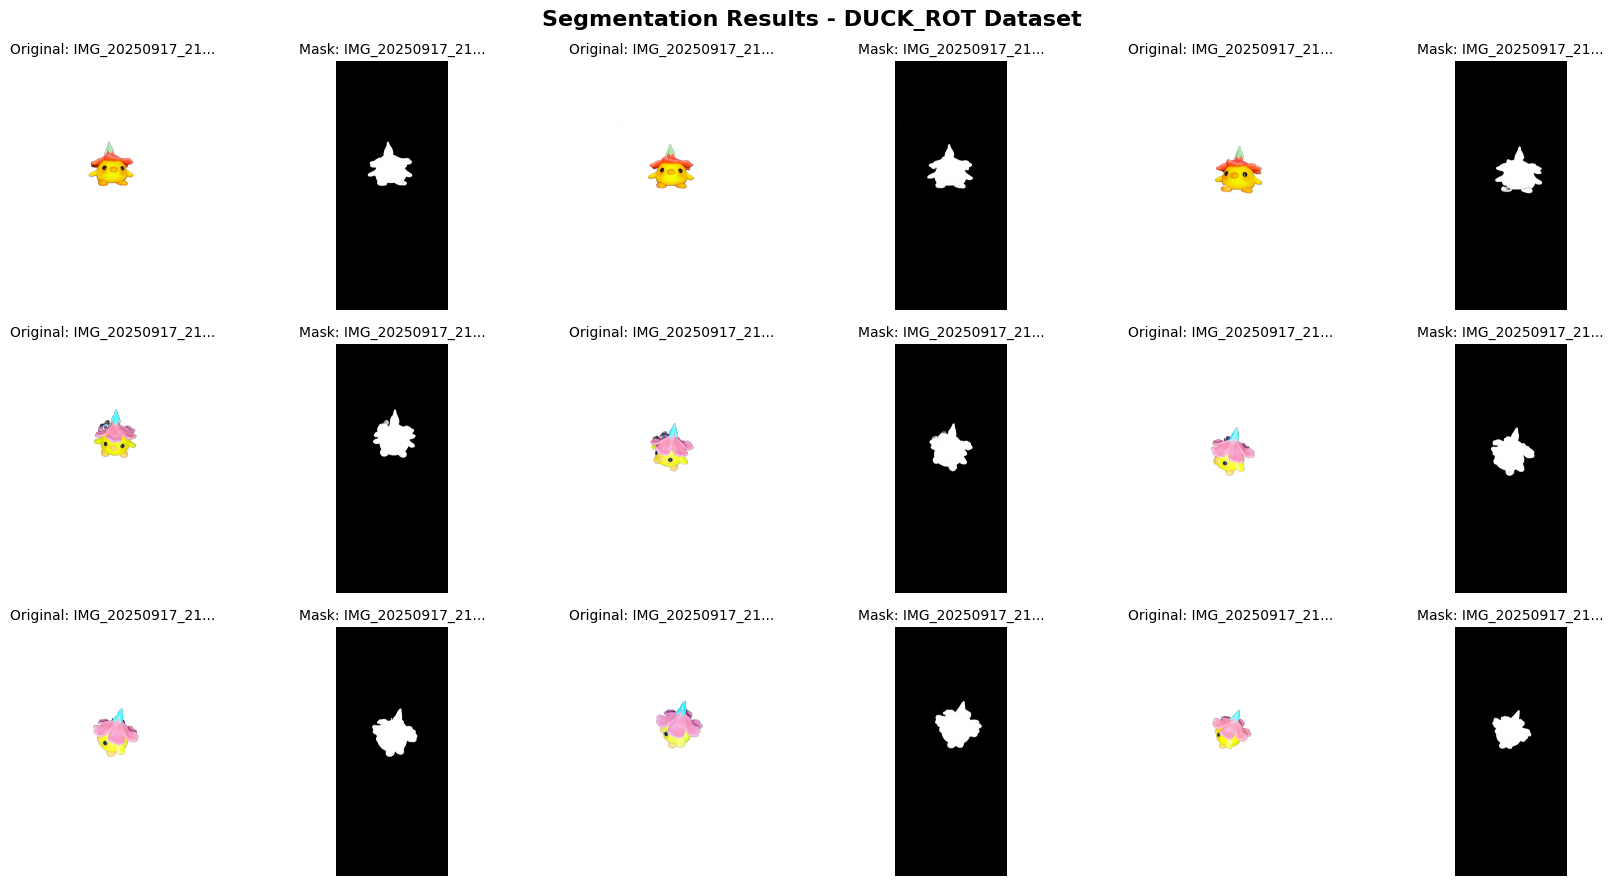

Processed 9 images from duck_rot
--------------------------------------------------


In [8]:
# Define segmentation function for BEN2 model
def segment_image_ben2(image):
    """
    Segment image using BEN2 model
    
    Args:
        image: PIL Image
    
    Returns:
        PIL Image: Segmented foreground mask
    """
    with torch.no_grad():
        foreground_mask = model.inference(image)
        # segmented_image = np.where(np.stack(3*[foreground_mask], axis=-1) > 0, np.array(image)[:,:,:3], 0)
        # segmented_image = Image.fromarray(segmented_image)
    return foreground_mask

# Function to segment multiple images and display results
def segment_and_display_datasets(dataset_images, images_per_dataset=9):
    """
    Segment multiple images from each dataset and display results in a grid
    """
    for dataset_name, images in dataset_images.items():
        print(f"Segmenting images from {dataset_name} dataset...")
        
        # Load more images if needed
        dataset_path = datasets[dataset_name]
        all_images = load_images_from_dataset(dataset_path, max_images=images_per_dataset)
        
        if len(all_images) == 0:
            print(f"No images found in {dataset_name}")
            continue
            
        # Take up to 9 images for display
        images_to_process = all_images[:images_per_dataset]
        
        # Create figure for this dataset
        fig, axes = plt.subplots(3, 6, figsize=(18, 9))
        fig.suptitle(f'Segmentation Results - {dataset_name.upper()} Dataset', fontsize=16, fontweight='bold')
        
        for i, (img, img_name) in enumerate(images_to_process):
            if i >= 9:  # Limit to 9 images (3x3 grid for each type)
                break
                
            # Segment the image
            foreground_mask = segment_image_ben2(img)
            
            # Convert mask to numpy array for visualization
            mask_array = np.array(foreground_mask)
            if mask_array.ndim == 3 and mask_array.shape[2] == 4:  # RGBA
                mask_array = mask_array[:, :, 3]  # Use alpha channel
            elif mask_array.ndim == 3:
                mask_array = cv2.cvtColor(mask_array, cv2.COLOR_RGB2GRAY)
            
            # Calculate positions in grid
            row = i // 3
            col_orig = (i % 3) * 2
            col_mask = col_orig + 1
            
            # Display original image
            axes[row, col_orig].imshow(img)
            axes[row, col_orig].set_title(f'Original: {img_name[:15]}...', fontsize=10)
            axes[row, col_orig].axis('off')
            
            # Display segmentation mask
            axes[row, col_mask].imshow(mask_array, cmap='gray')
            axes[row, col_mask].set_title(f'Mask: {img_name[:15]}...', fontsize=10)
            axes[row, col_mask].axis('off')
        
        # Hide unused subplots
        for i in range(len(images_to_process), 9):
            row = i // 3
            col_orig = (i % 3) * 2
            col_mask = col_orig + 1
            axes[row, col_orig].axis('off')
            axes[row, col_mask].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print(f"Processed {len(images_to_process)} images from {dataset_name}")
        print("-" * 50)

# Segment and display results for all datasets
if dataset_images:
    segment_and_display_datasets(dataset_images, images_per_dataset=9)
else:
    print("No dataset images loaded. Please check the dataset paths.")

## 4. Segmentation Pipeline

Implement the main segmentation pipeline that processes images and extracts foreground/background masks.

In [9]:
# Let's segment all of its images and save the cropped foregrounds to pure_colmap_duck_rot_seg/images folder
from tqdm import tqdm
os.makedirs(base_path / "pure_colmap_duck_rot_seg/images", exist_ok=True)
os.makedirs(base_path / "pure_colmap_duck_rot_crop/images", exist_ok=True)
os.makedirs(base_path / "pure_colmap_duck_rot_seg_sharp1x/images", exist_ok=True)
os.makedirs(base_path / "pure_colmap_duck_rot_seg_sharp2x/images", exist_ok=True)
for img, img_name in tqdm(load_images_from_dataset(datasets['duck_rot'], max_images=100)):
    # print(f"Segmenting and saving {img_name}...")
    seg_result = segment_image_ben2(img)
    # Convert RGBA mask to RGB with black background
    img_array = np.array(img.convert('RGB'))
    mask_array = np.array(seg_result)
    alpha_channel = mask_array[:, :, 3] / 255.0  # Normalize alpha to 0-1
    
    # Apply mask to create foreground image with black background
    fg_image = Image.fromarray((img_array * alpha_channel[:, :, np.newaxis]).astype(np.uint8))

    # Get bounding box of the duck (non-zero alpha regions)
    mask_binary = (alpha_channel > 0.1).astype(np.uint8)
    contours, _ = cv2.findContours(mask_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        # Get the largest contour (assuming it's the duck)
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        
        # Calculate center of the duck
        duck_center_x = x + w // 2
        duck_center_y = y + h // 2
        
        # Define 640x640 crop area centered on duck
        crop_size = 1000
        half_crop = crop_size // 2
        
        # Calculate crop boundaries
        left = max(0, duck_center_x - half_crop)
        top = max(0, duck_center_y - half_crop)
        right = min(img_array.shape[1], left + crop_size)
        bottom = min(img_array.shape[0], top + crop_size)
        
        # Adjust if crop goes beyond image boundaries
        if right - left < crop_size:
            left = max(0, right - crop_size)
        if bottom - top < crop_size:
            top = max(0, bottom - crop_size)
        
        # Crop the foreground image
        fg_cropped = fg_image.crop((left, top, left + crop_size, top + crop_size))

        # Also crop the original image for reference (optional)
        orig_cropped = img.crop((left, top, left + crop_size, top + crop_size)).convert('RGB')
        orig_cropped.save(base_path / "pure_colmap_duck_rot_crop/images" / img_name)

        # If crop is smaller than 640x640, pad with black
        if fg_cropped.size != (crop_size, crop_size):
            padded_img = Image.new('RGB', (crop_size, crop_size), (0, 0, 0))
            paste_x = (crop_size - fg_cropped.width) // 2
            paste_y = (crop_size - fg_cropped.height) // 2
            padded_img.paste(fg_cropped, (paste_x, paste_y))
            fg_image = padded_img
        else:
            fg_image = fg_cropped
    fg_image.save(base_path / "pure_colmap_duck_rot_seg/images" / img_name)

    # Apply sharpen filter to image
    kernel = np.array([[-1,-1,-1],
                        [-1, 9,-1],
                        [-1,-1,-1]])
    fg_image = cv2.filter2D(np.asarray(fg_image), -1, kernel)

    fg_image = Image.fromarray(fg_image)
    fg_image.save(base_path / "pure_colmap_duck_rot_seg_sharp1x/images" / img_name)

    # Apply sharpen filter to image (2x)
    fg_image = cv2.filter2D(np.asarray(fg_image), -1, kernel)

    fg_image = Image.fromarray(fg_image)
    fg_image.save(base_path / "pure_colmap_duck_rot_seg_sharp2x/images" / img_name)


100%|██████████| 64/64 [00:24<00:00,  2.65it/s]


In [12]:
os.makedirs(base_path / "pure_colmap_duck_rot_sharp1x/images", exist_ok=True)
os.makedirs(base_path / "pure_colmap_duck_rot_sharp2x/images", exist_ok=True)
for img, img_name in tqdm(load_images_from_dataset(datasets['duck_rot'], max_images=100)):
    # Apply sharpen filter to image
    kernel = np.array([[-1,-1,-1],
                        [-1, 9,-1],
                        [-1,-1,-1]])
    img_sharp = cv2.filter2D(np.asarray(img), -1, kernel)

    img_sharp = Image.fromarray(img_sharp)
    img_sharp.save(base_path / "pure_colmap_duck_rot_sharp1x/images" / img_name)

    # Apply sharpen filter to image (2x)
    img_sharp = cv2.filter2D(np.asarray(img_sharp), -1, kernel)

    img_sharp = Image.fromarray(img_sharp)
    img_sharp.save(base_path / "pure_colmap_duck_rot_sharp2x/images" / img_name)

100%|██████████| 64/64 [00:07<00:00,  8.92it/s]
